In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json
import pandas as pd
from collections import Counter

In [ ]:
df_balanceado = pd.read_csv('/content/drive/MyDrive/DATASET_TESIS_CIC/CLASIFICACIÓN/CB_balanceado_completo.csv')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [ ]:
# División del dataset
X = df_balanceado['text_cleaned'] # Lo que va leer
y = df_balanceado['category_single'] # Lo que va a predecir

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [ ]:
# Vectorizar texto con TF-IDF
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))  # Unigrama y bigrama, se usan los 10,000 más frecuentes
X_train_tfidf = vectorizer.fit_transform(X_train) # Aprende el vocabulario y transforma el texto de entrenamiento
X_test_tfidf = vectorizer.transform(X_test) # Transforma el texto de prueba usando el vocabulario aprendido

In [ ]:
# ENTRENAMIENTO
modelo = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42) # Máximo de iteraciones para asegurar que converge
modelo.fit(X_train_tfidf, y_train) # Equilibra clases menos frecuentes

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
# Predicción y evaluación
y_pred = modelo.predict(X_test_tfidf) # Predicciones del modelo

print("Evaluación del modelo:")
print(classification_report(y_test, y_pred))

Evaluación del modelo:
                   precision    recall  f1-score   support

             edad       0.92      0.88      0.90      2008
            etnia       0.72      0.80      0.76      1376
           género       0.66      0.77      0.71      2480
not_ciberbullying       0.90      0.82      0.86      8000
             odio       0.76      0.86      0.81      1251
            otros       0.80      0.89      0.84       449

         accuracy                           0.82     15564
        macro avg       0.79      0.84      0.81     15564
     weighted avg       0.83      0.82      0.83     15564



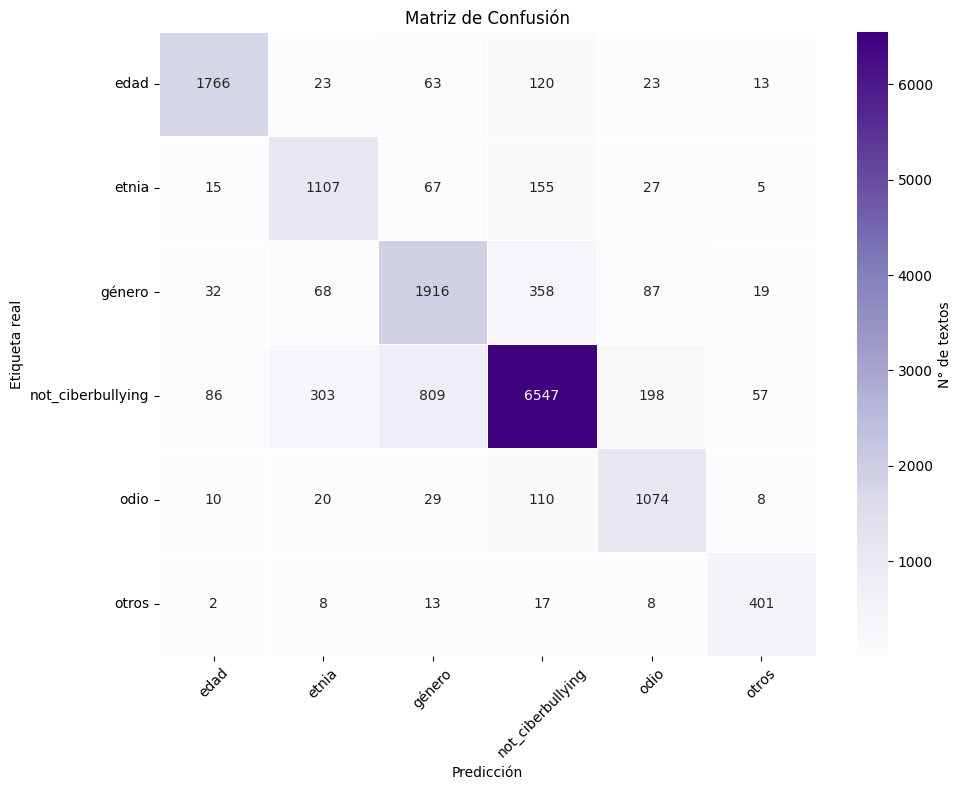

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Obtener matriz de confusión con etiquetas ordenadas
labels = sorted(df_balanceado['category_single'].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels, linewidths=0.5, cbar_kws={"label": "N° de textos"})
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de Confusión")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

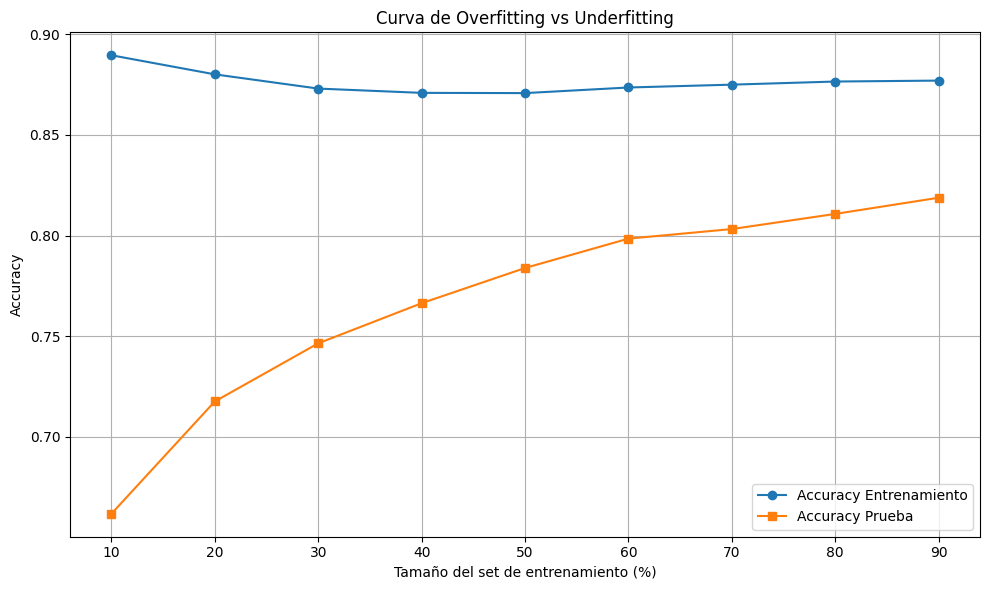

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Listas para guardar resultados
train_sizes = np.linspace(0.1, 0.9, 9)  # de 10% a 90% del entrenamiento
train_scores = []
test_scores = []

for size in train_sizes:
    X_train_part, _, y_train_part, _ = train_test_split(
        X_train, y_train, train_size=size, stratify=y_train, random_state=42)

    # Vectorización TF-IDF con mismo vocabulario
    X_train_part_tfidf = vectorizer.fit_transform(X_train_part)
    X_test_tfidf = vectorizer.transform(X_test)

    # Entrenar el modelo
    modelo = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    modelo.fit(X_train_part_tfidf, y_train_part)

    # Evaluar
    train_pred = modelo.predict(X_train_part_tfidf)
    test_pred = modelo.predict(X_test_tfidf)

    train_acc = accuracy_score(y_train_part, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Graficar resultados
plt.figure(figsize=(10, 6))
plt.plot(train_sizes * 100, train_scores, marker='o', label='Accuracy Entrenamiento')
plt.plot(train_sizes * 100, test_scores, marker='s', label='Accuracy Prueba')
plt.xlabel('Tamaño del set de entrenamiento (%)')
plt.ylabel('Accuracy')
plt.title('Curva de Overfitting vs Underfitting')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import joblib

# Guardar modelo
joblib.dump(modelo, 'modelo_logistica.pkl')

# Guardar vectorizador
joblib.dump(vectorizer, 'vectorizador_tfidf.pkl')

In [ ]:
import pandas as pd

# Creación de dataframe con los textos de prueba y sus predicciones
df_pred = pd.DataFrame({
    'text': X_test,
    'real': y_test,
    'prediccion': y_pred
})

# Si tienes columnas lat/lon, debes unirlas con X_test
df_pred = df_pred.merge(df_balanceado[['text_cleaned', 'lat', 'lon']], left_on='text', right_on='text_cleaned', how='left')

# Eliminar duplicados si los hubiera
df_pred = df_pred.drop_duplicates(subset='text')

# Guardar como CSV
df_pred.to_csv('predicciones_logistica.csv', index=False)

In [ ]:
import geopandas as gpd
from shapely.geometry import Point

# Guardar shp
df_geo = df_pred.dropna(subset=['lat', 'lon']).copy()
df_geo['geometry'] = df_geo.apply(lambda row: Point(row['lon'], row['lat']), axis=1)

gdf = gpd.GeoDataFrame(df_geo, geometry='geometry', crs='EPSG:4326')
gdf.to_file('predicciones_logistica.geojson', driver='GeoJSON')